# Steady Floodway Encroachment


In [1]:
from pathlib import Path
import logging
import os

import h5py
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon

import ras_commander

logging.disable(logging.CRITICAL)
from ras_commander import (
    HdfResultsPlan,
    HdfXsec,
    RasCmdr,
    RasExamples,
    RasFloodway,
    RasPlan,
    init_ras_project,
)


## Development Mode

When running this notebook from a source checkout instead of an installed package, start Jupyter from the repository root or add the repository root to `PYTHONPATH` before launching Jupyter. Generated example projects and run outputs are written under `working/` unless `RAS_COMMANDER_WORKDIR` is set.

# Steady Floodway Encroachment Authoring

This notebook demonstrates the steady-flow floodway authoring API on the official HEC-RAS "Example 6 - Floodway Determination" project. It parses existing encroachment records, authors Method 1 through Method 5 plans without GUI steps, computes those plans through `RasCmdr`, validates a computed floodway profile through `RasCheck`, and compares floodway widths across methods.

The figure sequence follows the same engineering workflow used in the HEC Example 6 documentation: establish the base/natural profile, create trial Method 4 and Method 5 encroachments, review surcharge and encroachment output, and use Method 1 station limits as the refined floodway definition. The added plots use HEC-style plan/profile conventions: river-station labels, cross-section linework, base versus floodway WSE overlays, target/limit annotations, and tabular pass/fail review.

HEC-RAS exposes five floodplain encroachment methods. HEC-2 method 6 energy targeting is represented in HEC-RAS by Method 5 with a maximum energy-change target.

References: [HEC-RAS Example 6 - Floodway Determination](https://www.hec.usace.army.mil/confluence/rasdocs/rasappguide/latest/floodway-determination-example-6) and [Steady Flow Floodway Encroachment Analysis](https://www.hec.usace.army.mil/confluence/rasdocs/rasum/6.3/performing-a-floodplain-encroachment-analysis/steady-flow-floodway-encroachment-analysis).


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    REPO_ROOT / "working" / "floodway_encroachment",
))
PROJECT_NAME = "Example 6 - Floodway Determination"
RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE",
    r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe",
))

assert RAS_EXE.exists(), f"HEC-RAS executable not found: {RAS_EXE}"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix="api_authoring",
)
ras_project = init_ras_project(project_path, str(RAS_EXE), load_results_summary=False)


def hdf_plan_path(plan_number: str) -> Path:
    return Path(ras_project.project_folder) / f"{ras_project.project_name}.p{plan_number}.hdf"


def hdf_geom_path() -> Path:
    return Path(ras_project.project_folder) / f"{ras_project.project_name}.g01.hdf"


print(f"ras-commander: {ras_commander.__version__}")
print(f"Project: {ras_project.project_name}")
print(f"Project folder: {ras_project.project_folder}")
display(ras_project.plan_df[["plan_number", "Plan Title", "Flow File", "Geom File"]])


ras-commander: 0.96.2
Project: FLODENCR
Project folder: I:\Symphony\ras-commander\CLB-497\notebook_runs\223_steady_floodway_encroachment\Example 6 - Floodway Determination_api_authoring


,plan_number,Plan Title,Flow File,Geom File
0,01,Method 5 Encroachment,01,01
1,05,Method 1 Encroachment,01,01
2,02,Method 4 Encroachment - Trial 1,02,01
3,04,Method 4 Encroachment - Trial 3,01,01
4,03,Method 4 Encroachment - Trial 2,01,01


## Hydraulic Context And Figure Plan

Before changing floodway inputs, the model context needs to show what controls the demonstration reach:

- Geometry: one 1D Beaver Creek reach named Kentwood, twelve cross sections, one bridge/control area near river station 5.39, and no 2D mesh.
- Boundary conditions: the 14,000 cfs base flow enters at the upstream end, with known downstream WSE values used to start the base and floodway profiles.
- Terrain context: this example has no RASMapper terrain file or CRS. The plan-view figures therefore use ground contours interpolated from the cross-section station/elevation arrays in the compiled HDF geometry.
- Floodway workflow: compute a natural profile, create Method 4 and Method 5 trial encroachments, compare resulting left/right encroachment stations and surcharge, then review whether each method stays within the 1.0 ft surcharge limit.


In [3]:
SURCHARGE_LIMIT_FT = 1.0
MODEL_CONTEXT_PLAN = "05"
HEC_COLORS = {
    "ground": "#3f3a2d",
    "reach": "#005ea8",
    "bank": "#667085",
    "xs": "#4d4d4d",
    "base": "#1f77b4",
    "floodway": "#d62728",
    "target": "#7f3c8d",
    "fringe": "#f28e2b",
    "corridor": "#2ca25f",
    "grid": "#d0d5dd",
}
METHOD_COLORS = {
    "Method 1": "#1f77b4",
    "Method 2": "#2ca02c",
    "Method 3": "#9467bd",
    "Method 4 0.5 ft": "#ff7f0e",
    "Method 4 1.0 ft": "#d62728",
    "Method 5 0.5 ft": "#17becf",
    "Method 5 1.0 ft": "#111827",
}

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "axes.edgecolor": "#344054",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "font.family": "DejaVu Sans",
})


def clean_station(value) -> float:
    return float(str(value).replace("*", "").strip())


def format_station_label(value) -> str:
    return str(value).strip()


def decode(value):
    if isinstance(value, bytes):
        return value.decode("utf-8").strip()
    return str(value).strip()


def xs_attr_value(attr, *names):
    for name in names:
        if name in attr.dtype.names:
            return decode(attr[name])
    return ""


def apply_text_outline(text):
    text.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground="white"),
        path_effects.Normal(),
    ])
    return text


def format_hec_axis(ax, title: str, xlabel: str, ylabel: str, invert_station: bool = False):
    ax.set_title(title, loc="left", fontweight="bold", pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, color=HEC_COLORS["grid"], linewidth=0.6, alpha=0.75)
    if invert_station:
        ax.invert_xaxis()
    return ax


def add_north_arrow(ax, x=0.94, y=0.88):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - 0.12),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "lw": 1.4, "color": "#111827"},
    )


def add_scale_bar(ax, length=None):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx = xmax - xmin
    dy = ymax - ymin
    if length is None:
        candidates = np.array([0.02, 0.05, 0.10, 0.20, 0.50, 1.00])
        target = dx / 5
        length = candidates[candidates <= target].max() if np.any(candidates <= target) else candidates[0]
    x0 = xmin + 0.06 * dx
    y0 = ymin + 0.07 * dy
    ax.plot([x0, x0 + length], [y0, y0], color="#111827", lw=2.2, solid_capstyle="butt", zorder=10)
    ax.plot([x0, x0], [y0 - 0.01 * dy, y0 + 0.01 * dy], color="#111827", lw=1.2, zorder=10)
    ax.plot([x0 + length, x0 + length], [y0 - 0.01 * dy, y0 + 0.01 * dy], color="#111827", lw=1.2, zorder=10)
    label = f"{length:.2f} mi model units"
    text = ax.text(x0 + length / 2, y0 + 0.025 * dy, label, ha="center", va="bottom", fontsize=8, zorder=11)
    apply_text_outline(text)


def load_geometry_layers():
    xs_gdf = HdfXsec.get_cross_sections(hdf_geom_path()).copy()
    assert not xs_gdf.empty, "No cross sections were read from the geometry HDF."
    xs_gdf["station_num"] = xs_gdf["RS"].map(clean_station)
    xs_gdf = xs_gdf.sort_values("station_num", ascending=False).reset_index(drop=True)
    reaches_gdf = HdfXsec.get_river_centerlines(hdf_geom_path())
    bank_gdf = HdfXsec.get_river_bank_lines(hdf_geom_path())
    return xs_gdf, reaches_gdf, bank_gdf


def xs_station_bounds(xs_row):
    station_elev = np.asarray(xs_row["station_elevation"], dtype=float)
    return float(np.nanmin(station_elev[:, 0])), float(np.nanmax(station_elev[:, 0]))


def point_at_xs_station(xs_row, station):
    sta_min, sta_max = xs_station_bounds(xs_row)
    if np.isclose(sta_max, sta_min):
        fraction = 0.5
    else:
        fraction = np.clip((float(station) - sta_min) / (sta_max - sta_min), 0, 1)
    return xs_row.geometry.interpolate(fraction * xs_row.geometry.length)


def xs_midpoint(xs_row):
    return xs_row.geometry.interpolate(xs_row.geometry.length / 2)


def xs_ground_points(xs_gdf):
    rows = []
    for _, xs_row in xs_gdf.iterrows():
        station_elev = np.asarray(xs_row["station_elevation"], dtype=float)
        sta_min, sta_max = xs_station_bounds(xs_row)
        for station, elev in station_elev:
            if not np.isfinite(station) or not np.isfinite(elev):
                continue
            fraction = 0.5 if np.isclose(sta_max, sta_min) else np.clip((station - sta_min) / (sta_max - sta_min), 0, 1)
            point = xs_row.geometry.interpolate(fraction * xs_row.geometry.length)
            rows.append({"x": point.x, "y": point.y, "elev": float(elev)})
    points = pd.DataFrame(rows)
    if points.empty:
        return points
    points["xr"] = points["x"].round(6)
    points["yr"] = points["y"].round(6)
    return (
        points.groupby(["xr", "yr"], as_index=False)
        .agg(x=("x", "mean"), y=("y", "mean"), elev=("elev", "mean"))
    )


def plot_terrain_context(ax, xs_gdf, filled=True, alpha=0.25):
    points = xs_ground_points(xs_gdf)
    if len(points) < 3:
        return None
    try:
        triangulation = mtri.Triangulation(points["x"].to_numpy(), points["y"].to_numpy())
        levels = np.linspace(points["elev"].min(), points["elev"].max(), 12)
        contour = None
        if filled:
            contour = ax.tricontourf(
                triangulation,
                points["elev"].to_numpy(),
                levels=levels,
                cmap="gist_earth",
                alpha=alpha,
                zorder=0,
            )
        lines = ax.tricontour(
            triangulation,
            points["elev"].to_numpy(),
            levels=levels,
            colors="#6b7280",
            linewidths=0.45,
            alpha=0.65,
            zorder=1,
        )
        ax.clabel(lines, inline=True, fontsize=6, fmt="%.0f", colors="#475467")
        return contour
    except Exception as exc:
        text = ax.text(
            0.02,
            0.02,
            f"XS ground contours unavailable: {exc}",
            transform=ax.transAxes,
            fontsize=8,
            color="#7a271a",
            va="bottom",
        )
        apply_text_outline(text)
        return None


def plot_model_context(ax, xs_gdf, reaches_gdf=None, bank_gdf=None, label_xs=True):
    if bank_gdf is not None and not bank_gdf.empty:
        for geom in bank_gdf.geometry:
            ax.plot(*geom.xy, color=HEC_COLORS["bank"], lw=1.1, ls="--", alpha=0.75, zorder=3)

    if reaches_gdf is not None and not reaches_gdf.empty:
        for geom in reaches_gdf.geometry:
            ax.plot(*geom.xy, color=HEC_COLORS["reach"], lw=2.6, zorder=4)

    for _, xs_row in xs_gdf.iterrows():
        ax.plot(*xs_row.geometry.xy, color=HEC_COLORS["xs"], lw=0.9, alpha=0.75, zorder=5)
        if label_xs:
            label_fraction = 0.22 if xs_row["station_num"] <= 5.13 else 0.08
            label_ha = "right" if xs_row["station_num"] <= 5.13 else "left"
            label_point = xs_row.geometry.interpolate(xs_row.geometry.length * label_fraction)
            label = ax.text(
                label_point.x,
                label_point.y,
                f"RS {format_station_label(xs_row['RS'])}",
                fontsize=7,
                color="#111827",
                ha=label_ha,
                va="bottom",
                zorder=8,
                clip_on=False,
            )
            apply_text_outline(label)

    upstream = xs_midpoint(xs_gdf.iloc[0])
    downstream = xs_midpoint(xs_gdf.iloc[-1])
    ax.annotate(
        "Flow",
        xy=(downstream.x, downstream.y),
        xytext=(upstream.x, upstream.y),
        arrowprops={"arrowstyle": "->", "lw": 1.5, "color": HEC_COLORS["reach"]},
        color=HEC_COLORS["reach"],
        fontsize=9,
        fontweight="bold",
        zorder=9,
    )

    bridge_idx = (xs_gdf["station_num"] - 5.39).abs().idxmin()
    bridge_row = xs_gdf.loc[bridge_idx]
    bridge_point = xs_midpoint(bridge_row)
    ax.scatter([bridge_point.x], [bridge_point.y], marker="s", s=42, color="#8b0000", zorder=9)
    note = ax.text(
        bridge_point.x,
        bridge_point.y,
        "  bridge control\n  near RS 5.39",
        fontsize=8,
        color="#8b0000",
        ha="left",
        va="center",
        zorder=10,
    )
    apply_text_outline(note)

    upstream_note = ax.text(upstream.x + 0.01, upstream.y - 0.02, "upstream flow\n14,000 cfs", fontsize=8, color="#003e73", zorder=10)
    downstream_note = ax.text(downstream.x - 0.15, downstream.y + 0.07, "downstream\nknown WSE", fontsize=8, color="#003e73", zorder=10)
    apply_text_outline(upstream_note)
    apply_text_outline(downstream_note)


def finish_plan_map(ax, title):
    ax.set_title(title, loc="left", fontweight="bold", pad=10)
    ax.set_xlabel("Model X coordinate (mi)")
    ax.set_ylabel("Model Y coordinate (mi)")
    ax.set_aspect("equal", adjustable="box")
    ax.margins(0.20)
    add_north_arrow(ax)
    add_scale_bar(ax)


def corridor_points_for_method(width_df, xs_gdf, method_label):
    data = (
        width_df[(width_df["method"] == method_label) & width_df["floodway_width"].notna()]
        .sort_values("station_num", ascending=False)
    )
    records = []
    for _, width_row in data.iterrows():
        xs_matches = xs_gdf[np.isclose(xs_gdf["station_num"], width_row["station_num"])]
        if xs_matches.empty:
            continue
        xs_row = xs_matches.iloc[0]
        left_pt = point_at_xs_station(xs_row, width_row["encroach_left"])
        right_pt = point_at_xs_station(xs_row, width_row["encroach_right"])
        records.append({
            "station_num": width_row["station_num"],
            "station": width_row["station"],
            "left_pt": left_pt,
            "right_pt": right_pt,
            "width": width_row["floodway_width"],
        })
    return pd.DataFrame(records)


def plot_encroachment_corridor(ax, width_df, xs_gdf, method_label, color, fill_alpha=0.10, mark_points=False):
    corridor = corridor_points_for_method(width_df, xs_gdf, method_label)
    if corridor.empty:
        return corridor

    left_coords = [(pt.x, pt.y) for pt in corridor["left_pt"]]
    right_coords = [(pt.x, pt.y) for pt in corridor["right_pt"]]
    if len(corridor) >= 3:
        polygon = MplPolygon(
            left_coords + list(reversed(right_coords)),
            closed=True,
            facecolor=color,
            edgecolor=color,
            linewidth=1.1,
            alpha=fill_alpha,
            zorder=6,
        )
        ax.add_patch(polygon)

    ax.plot([x for x, _ in left_coords], [y for _, y in left_coords], color=color, lw=1.8, zorder=7)
    ax.plot([x for x, _ in right_coords], [y for _, y in right_coords], color=color, lw=1.8, zorder=7)
    for _, row in corridor.iterrows():
        ax.plot([row["left_pt"].x, row["right_pt"].x], [row["left_pt"].y, row["right_pt"].y], color=color, lw=1.1, alpha=0.75, zorder=7)
    if mark_points:
        ax.scatter([pt.x for pt in corridor["left_pt"]], [pt.y for pt in corridor["left_pt"]], marker="<", s=28, color=color, edgecolor="white", linewidth=0.4, zorder=9)
        ax.scatter([pt.x for pt in corridor["right_pt"]], [pt.y for pt in corridor["right_pt"]], marker=">", s=28, color=color, edgecolor="white", linewidth=0.4, zorder=9)
    return corridor


## Overall Model Map

The first figure compiles the template plan so the geometry HDF is available, then plots the Beaver Creek/Kentwood reach, cross sections, bank lines, and the bridge/control area. Since the example project does not include a georeferenced RASMapper terrain, the terrain context is shown as contours interpolated from the cross-section ground profiles.


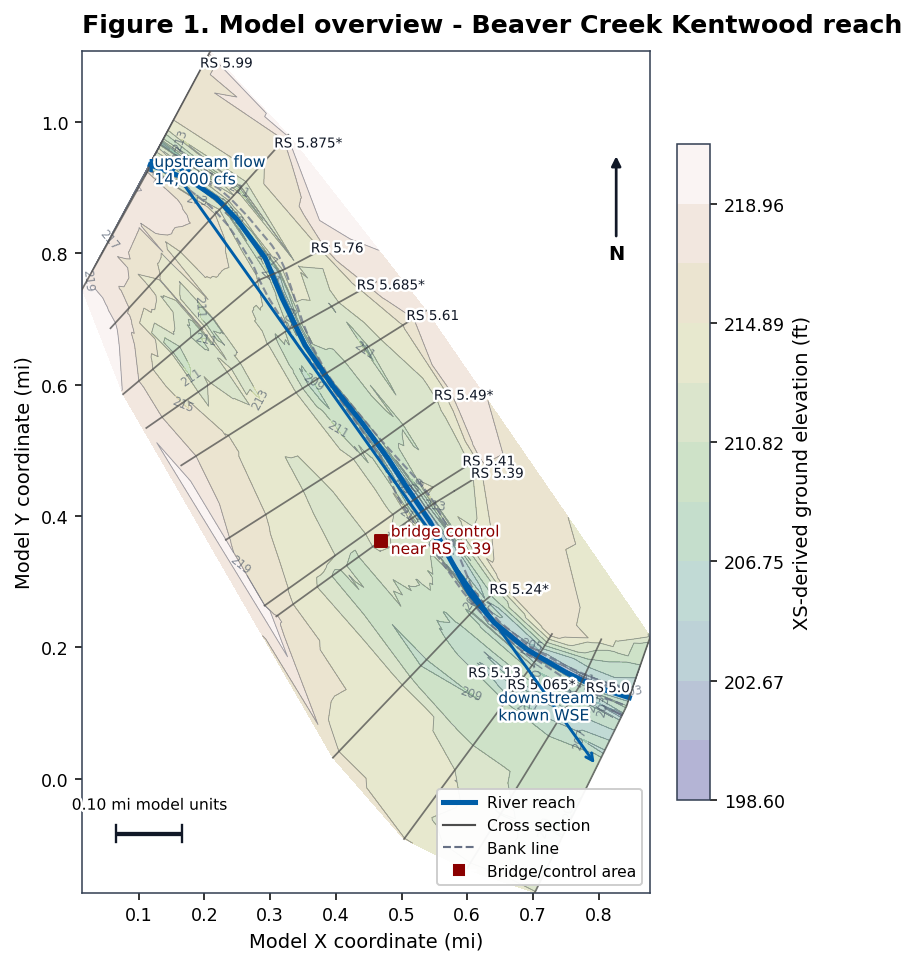

In [4]:
if not hdf_geom_path().exists() or not hdf_plan_path(MODEL_CONTEXT_PLAN).exists():
    context_result = RasCmdr.compute_plan(
        MODEL_CONTEXT_PLAN,
        ras_object=ras_project,
        clear_geompre=True,
        force_rerun=True,
        num_cores=1,
        verify=True,
    )
    assert context_result, f"HEC-RAS context plan {MODEL_CONTEXT_PLAN} failed"

geometry_xs, river_reaches, bank_lines = load_geometry_layers()

fig, ax = plt.subplots(figsize=(10, 7))
terrain = plot_terrain_context(ax, geometry_xs, filled=True, alpha=0.30)
plot_model_context(ax, geometry_xs, river_reaches, bank_lines, label_xs=True)
finish_plan_map(ax, "Figure 1. Model overview - Beaver Creek Kentwood reach")

legend_handles = [
    Line2D([0], [0], color=HEC_COLORS["reach"], lw=2.6, label="River reach"),
    Line2D([0], [0], color=HEC_COLORS["xs"], lw=1.1, label="Cross section"),
    Line2D([0], [0], color=HEC_COLORS["bank"], lw=1.1, ls="--", label="Bank line"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#8b0000", markersize=7, label="Bridge/control area"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, framealpha=0.95)
if terrain is not None:
    cbar = fig.colorbar(terrain, ax=ax, shrink=0.78, pad=0.02)
    cbar.set_label("XS-derived ground elevation (ft)")
plt.tight_layout()
plt.show()


## Existing Encroachment Records

The example project already contains Method 1, Method 4, and Method 5 records. These are parsed from plan text before any new authoring.

In [5]:
existing_frames = []
for plan_number in ["01", "02", "05"]:
    parsed = RasFloodway.parse_encroachments(plan_number, ras_object=ras_project).copy()
    parsed["plan_number"] = plan_number
    parsed["plan_title"] = RasPlan.get_plan_title(plan_number, ras_object=ras_project)
    existing_frames.append(parsed)

existing_encroachments = pd.concat(existing_frames, ignore_index=True)
summary = (
    existing_encroachments
    .groupby(["plan_number", "plan_title", "method"], dropna=False)
    .size()
    .reset_index(name="records")
)
display(summary)
display(
    existing_encroachments[
        ["plan_number", "river", "reach", "node", "profile_number", "method", "value_1", "value_2"]
    ].head(18)
)

,plan_number,plan_title,method,records
0,01,Method 5 Encroachment,5.0,13
1,02,Method 4 Encroachment - Trial 1,0.0,24
2,02,Method 4 Encroachment - Trial 1,1.0,2
3,02,Method 4 Encroachment - Trial 1,4.0,26
4,02,Method 4 Encroachment - Trial 1,NaN,26
5,05,Method 1 Encroachment,1.0,13
6,05,Method 1 Encroachment,4.0,13


,plan_number,river,reach,node,profile_number,method,value_1,value_2
0,01,Beaver Creek,Kentwood,5.99,2,5.0,1.0,1.2
1,01,Beaver Creek,Kentwood,5.875*,2,5.0,1.0,1.2
2,01,Beaver Creek,Kentwood,5.76,2,5.0,1.0,1.2
3,01,Beaver Creek,Kentwood,5.685*,2,5.0,1.0,1.2
4,01,Beaver Creek,Kentwood,5.61,2,5.0,1.0,1.2
5,01,Beaver Creek,Kentwood,5.49*,2,5.0,1.0,1.2
6,01,Beaver Creek,Kentwood,5.41,2,5.0,1.0,1.2
7,01,Beaver Creek,Kentwood,5.4,2,5.0,1.0,1.2
8,01,Beaver Creek,Kentwood,5.39,2,5.0,1.0,1.2
9,01,Beaver Creek,Kentwood,5.24*,2,5.0,1.0,1.2


## Author Method 1-5 Plans

The cloned plans keep the original example project intact. Method 4 and Method 5 clone their own steady-flow files, then `RasFloodway` creates new floodway profiles and downstream starting WSE values.

In [6]:
def clone_plan(template_plan: str, title: str, shortid: str) -> str:
    return RasPlan.clone_plan(
        template_plan,
        new_title=title,
        new_plan_shortid=shortid,
        ras_object=ras_project,
    )


def clone_steady(template_flow: str, title: str) -> str:
    return RasPlan.clone_steady(
        template_flow,
        new_title=title,
        ras_object=ras_project,
    )


source_m1 = RasFloodway.parse_encroachments("05", ras_object=ras_project)
method1_records = (
    source_m1[(source_m1["reach"] == "Kentwood") & (source_m1["method"] == 1)]
    [["river", "reach", "node", "method", "left_station", "right_station"]]
    .to_dict("records")
)
locations = [
    {"river": row["river"], "reach": row["reach"], "node": row["node"]}
    for row in method1_records
]

method2_records = [
    {
        "river": row["river"],
        "reach": row["reach"],
        "node": row["node"],
        "method": 2,
        "fixed_top_width": row["right_station"] - row["left_station"],
    }
    for row in method1_records
]

method3_records = [
    {
        "river": row["river"],
        "reach": row["reach"],
        "node": row["node"],
        "method": 3,
        "conveyance_reduction_percent": 25,
    }
    for row in method1_records
]

plan_m1 = clone_plan("05", "API Method 1 Stations", "API_M1")
RasFloodway.set_encroachments(
    plan_m1,
    method1_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

plan_m2 = clone_plan("05", "API Method 2 Width", "API_M2")
RasFloodway.set_encroachments(
    plan_m2,
    method2_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

plan_m3 = clone_plan("05", "API Method 3 Conveyance", "API_M3")
RasFloodway.set_encroachments(
    plan_m3,
    method3_records,
    encroach_param=(-1, 10, 10),
    profile_count=2,
    ras_object=ras_project,
)

flow_m4 = clone_steady("01", "API Method 4 Flow")
plan_m4 = clone_plan("05", "API Method 4 Trials", "API_M4")
RasPlan.set_steady(plan_m4, flow_m4, ras_object=ras_project)
m4_result = RasFloodway.create_method_4_trial_profiles(
    plan_m4,
    targets=[0.5, 1.0],
    flow_number_or_path=flow_m4,
    base_profile=1,
    profile_names=["M4 0.5 ft", "M4 1.0 ft"],
    locations=locations,
    starting_wse_deltas=[0.5, 1.0],
    metadata={"notebook": "223_steady_floodway_encroachment"},
    ras_object=ras_project,
)

flow_m5 = clone_steady("01", "API Method 5 Flow")
plan_m5 = clone_plan("05", "API Method 5 Energy", "API_M5")
RasPlan.set_steady(plan_m5, flow_m5, ras_object=ras_project)
m5_result = RasFloodway.create_method_5_trial_profiles(
    plan_m5,
    targets=[0.5, 1.0],
    flow_number_or_path=flow_m5,
    base_profile=1,
    profile_names=["M5 0.5 ft", "M5 1.0 ft"],
    locations=locations,
    starting_wse_deltas=[0.5, 1.0],
    energy_targets=[0.25, 0.25],
    metadata={"notebook": "223_steady_floodway_encroachment"},
    ras_object=ras_project,
)

authored_plans = {
    "Method 1": {"plan": plan_m1, "floodway_profile": "PF#2"},
    "Method 2": {"plan": plan_m2, "floodway_profile": "PF#2"},
    "Method 3": {"plan": plan_m3, "floodway_profile": "PF#2"},
    "Method 4 0.5 ft": {"plan": plan_m4, "floodway_profile": "M4 0.5 ft"},
    "Method 4 1.0 ft": {"plan": plan_m4, "floodway_profile": "M4 1.0 ft"},
    "Method 5 0.5 ft": {"plan": plan_m5, "floodway_profile": "M5 0.5 ft"},
    "Method 5 1.0 ft": {"plan": plan_m5, "floodway_profile": "M5 1.0 ft"},
}

setup_preview = []
for label, info in authored_plans.items():
    enc = RasFloodway.parse_encroachments(info["plan"], ras_object=ras_project)
    methods = sorted(enc.loc[enc["method"] > 0, "method"].dropna().unique().astype(int).tolist())
    setup_preview.append({
        "label": label,
        "plan": info["plan"],
        "floodway_profile": info["floodway_profile"],
        "methods_written": methods,
        "records": int((enc["method"] > 0).sum()),
    })

display(pd.DataFrame(setup_preview))
display(m4_result["encroachments"].head())


,label,plan,floodway_profile,methods_written,records
0,Method 1,06,PF#2,[1],13
1,Method 2,07,PF#2,[2],13
2,Method 3,08,PF#2,[3],13
3,Method 4 0.5 ft,09,M4 0.5 ft,[4],26
4,Method 4 1.0 ft,09,M4 1.0 ft,[4],26
5,Method 5 0.5 ft,10,M5 0.5 ft,[5],26
6,Method 5 1.0 ft,10,M5 1.0 ft,[5],26


,river,reach,node,profile_number,profile_slot,method,value_1,value_2,left_station,right_station,target_top_width,conveyance_reduction_percent,target_surcharge,energy_target,encroach_param_1,encroach_param_2,encroach_param_3,profile_count,plan_path,line_number
0,Beaver Creek,Kentwood,5.99,2,1,0,0.0,0.0,None,None,None,None,NaN,None,-1.0,0.0,0.0,4.0,I:\Symphony\ras-commander\CLB-497\notebook_run...,22
1,Beaver Creek,Kentwood,5.99,3,2,4,0.5,0.0,None,None,None,None,0.5,None,-1.0,0.0,0.0,4.0,I:\Symphony\ras-commander\CLB-497\notebook_run...,22
2,Beaver Creek,Kentwood,5.99,4,3,4,1.0,0.0,None,None,None,None,1.0,None,-1.0,0.0,0.0,4.0,I:\Symphony\ras-commander\CLB-497\notebook_run...,22
3,Beaver Creek,Kentwood,5.875*,2,1,0,0.0,0.0,None,None,None,None,NaN,None,-1.0,0.0,0.0,4.0,I:\Symphony\ras-commander\CLB-497\notebook_run...,24
4,Beaver Creek,Kentwood,5.875*,3,2,4,0.5,0.0,None,None,None,None,0.5,None,-1.0,0.0,0.0,4.0,I:\Symphony\ras-commander\CLB-497\notebook_run...,24


## Encroachment Targets On Profile

The target markers are the Method 4 target WSEs, calculated as base-profile WSE plus the authored target surcharge at each encroached river station.

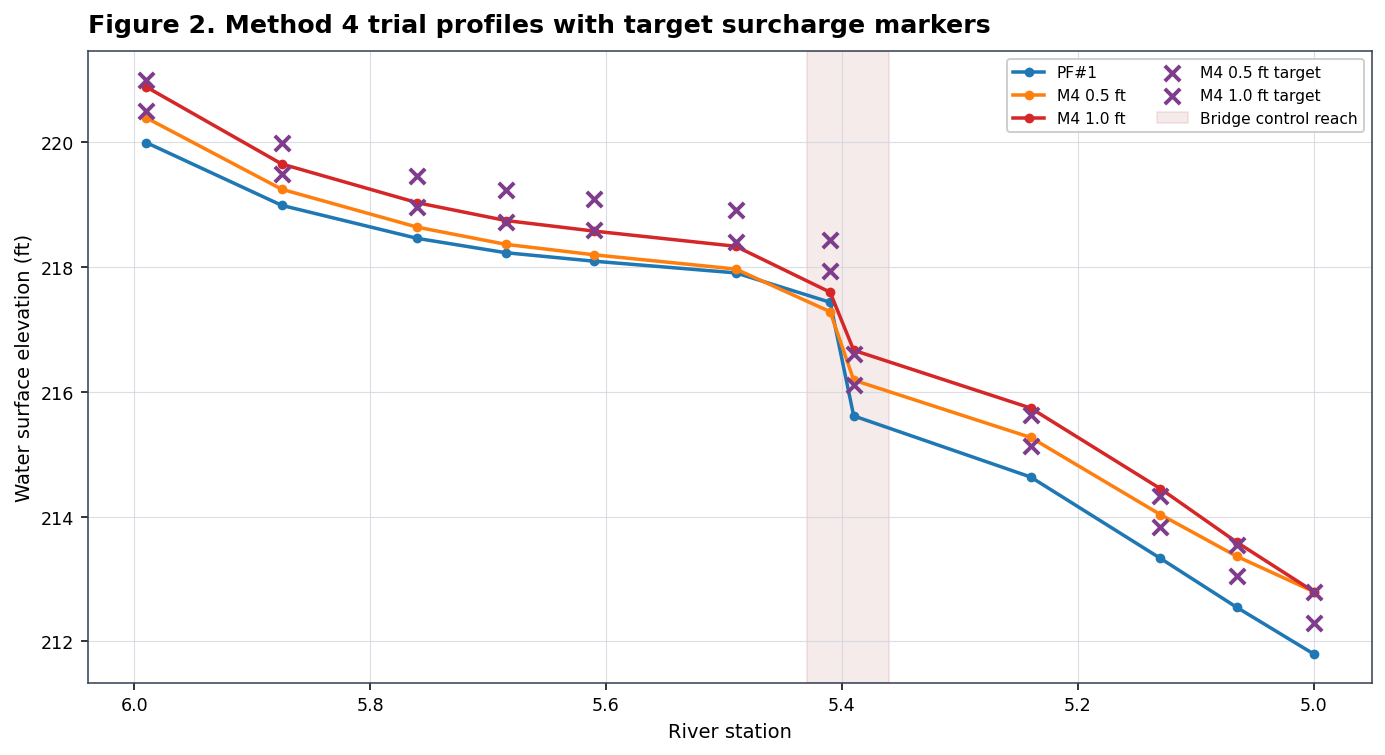

In [7]:
for plan_number in sorted({info["plan"] for info in authored_plans.values()}):
    result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras_project,
        clear_geompre=True,
        force_rerun=True,
        num_cores=1,
        verify=True,
    )
    assert result, f"HEC-RAS plan {plan_number} failed"

m4_hdf = hdf_plan_path(plan_m4)
m4_results = HdfResultsPlan.get_steady_results(m4_hdf)
m4_results["station_num"] = m4_results["node_id"].map(clean_station)
m4_results = m4_results.sort_values("station_num")

m4_profiles = ["PF#1", *m4_result["new_profile_names"]]
fig, ax = plt.subplots(figsize=(10, 5.5))
profile_colors = {"PF#1": HEC_COLORS["base"], "M4 0.5 ft": "#ff7f0e", "M4 1.0 ft": HEC_COLORS["floodway"]}
for profile in m4_profiles:
    data = m4_results[m4_results["profile"] == profile]
    ax.plot(
        data["station_num"],
        data["wsel"],
        marker="o",
        markersize=4,
        linewidth=1.8,
        color=profile_colors.get(profile),
        label=profile,
    )

base = (
    m4_results[m4_results["profile"] == "PF#1"]
    [["node_id", "wsel"]]
    .rename(columns={"wsel": "base_wsel"})
)
m4_targets = m4_result["encroachments"].copy()
m4_targets = m4_targets[m4_targets["method"] == 4]
m4_targets["station_num"] = m4_targets["node"].map(clean_station)
m4_targets = m4_targets.merge(base, left_on="node", right_on="node_id", how="inner")
m4_targets["target_wsel"] = m4_targets["base_wsel"] + m4_targets["target_surcharge"]
profile_name_by_number = {
    number: name for number, name in zip(m4_result["new_profile_numbers"], m4_result["new_profile_names"])
}

for profile_number, target_data in m4_targets.groupby("profile_number"):
    profile_name = profile_name_by_number.get(profile_number, f"Profile {profile_number}")
    ax.scatter(
        target_data["station_num"],
        target_data["target_wsel"],
        s=62,
        marker="x",
        linewidths=2.0,
        color=HEC_COLORS["target"],
        label=f"{profile_name} target",
        zorder=5,
    )

ax.axvspan(5.36, 5.43, color="#8b0000", alpha=0.08, label="Bridge control reach")
format_hec_axis(
    ax,
    "Figure 2. Method 4 trial profiles with target surcharge markers",
    "River station",
    "Water surface elevation (ft)",
    invert_station=True,
)
ax.legend(ncol=2, loc="best", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()


## Post-Run Floodway Validation

The authoring API delegates post-run checks to `RasCheck.check_floodways`. The following check uses the Method 5 1.0 ft profile, then later figures compare all authored methods against the same surcharge limit.


In [8]:
validation = RasFloodway.check_floodway(
    hdf_plan_path(plan_m5),
    hdf_geom_path(),
    base_profile="PF#1",
    floodway_profile="M5 1.0 ft",
    surcharge_limit=1.0,
)
print(validation)

validation_rows = [
    {
        "message_id": message.message_id,
        "severity": message.severity.value,
        "river": message.river,
        "reach": message.reach,
        "station": message.station,
        "value": message.value,
        "threshold": message.threshold,
    }
    for message in validation.messages
]
validation_df = pd.DataFrame(validation_rows)
if validation_df.empty:
    print("No floodway messages returned.")
else:
    display(validation_df.groupby(["severity", "message_id"]).size().reset_index(name="count"))
    display(validation_df.head(10))

CheckResults(messages=9, errors=0, warnings=6)


,severity,message_id,count
0,INFO,FW_SC_04,1
1,INFO,FW_SW_01,1
2,INFO,FW_SW_04,1
3,WARNING,FW_SC_02,5
4,WARNING,FW_SW_02,1


,message_id,severity,river,reach,station,value,threshold
0,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.76,-0.048401,NaN
1,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.685*,-0.169479,NaN
2,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.61,-0.199219,NaN
3,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.49*,-0.270981,NaN
4,FW_SC_02,WARNING,Beaver Creek,Kentwood,5.41,-0.413177,NaN
5,FW_SC_04,INFO,Beaver Creek,Kentwood,5.0,1.000000,1.0
6,FW_SW_01,INFO,Beaver Creek,Kentwood,5.0,212.800003,NaN
7,FW_SW_02,WARNING,Beaver Creek,Kentwood,5.0,1.000000,0.5
8,FW_SW_04,INFO,Beaver Creek,Kentwood,5.0,212.800003,209.0


## Floodway Width Comparison

The HDF results contain computed left and right encroachment stations. Floodway width is the right station minus the left station for each floodway profile. This plot is styled as an HEC review figure: river station runs upstream-to-downstream from left to right, the bridge-control reach is highlighted, and trial profiles are compared directly.


,method,profile,sections,min_width,mean_width,max_width
0,Method 1,PF#2,12,595.6,750.9,928.6
1,Method 2,PF#2,12,595.6,750.9,928.6
2,Method 3,PF#2,12,316.9,673.7,923.5
3,Method 4 0.5 ft,M4 0.5 ft,12,723.1,1016.3,1231.0
4,Method 4 1.0 ft,M4 1.0 ft,12,545.9,796.2,1012.5
5,Method 5 0.5 ft,M5 0.5 ft,12,927.6,1310.6,1888.0
6,Method 5 1.0 ft,M5 1.0 ft,12,951.2,1374.3,1788.0


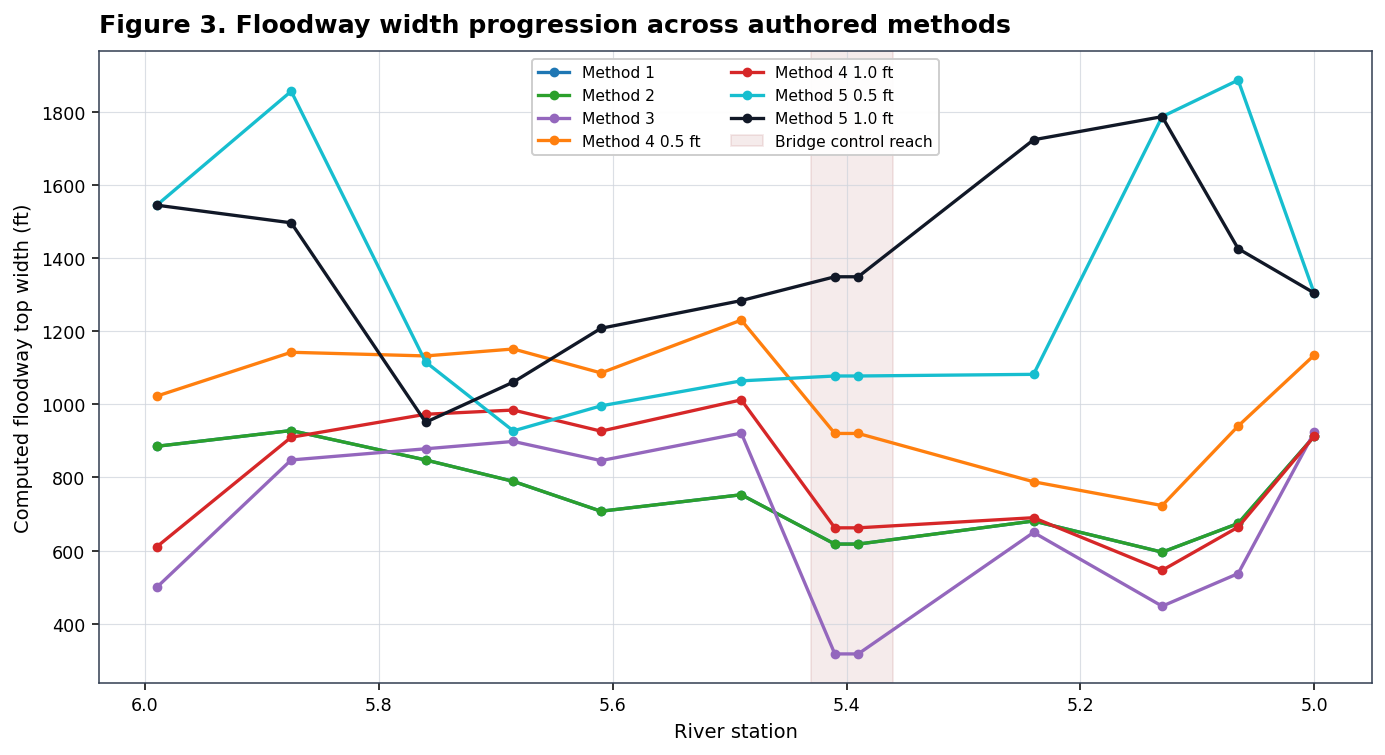

In [9]:
def extract_floodway_widths(plan_hdf: Path, method_label: str, profile_name: str) -> pd.DataFrame:
    base = "Results/Steady/Output/Output Blocks/Base Output/Steady Profiles"
    add = f"{base}/Cross Sections/Additional Variables"
    with h5py.File(plan_hdf, "r") as hdf:
        profiles = [decode(name) for name in hdf[f"{base}/Profile Names"][()]]
        profile_index = profiles.index(profile_name)
        left = hdf[f"{add}/Encroachment Station Left"][()]
        right = hdf[f"{add}/Encroachment Station Right"][()]
        top_width = hdf[f"{add}/Top Width Total"][()]
        attrs_path = "Results/Steady/Output/Geometry Info/Cross Section Attributes"
        attrs = hdf[attrs_path][()]

        rows = []
        for xs_index, attr in enumerate(attrs):
            encr_left = float(left[profile_index, xs_index])
            encr_right = float(right[profile_index, xs_index])
            width = encr_right - encr_left
            rows.append({
                "method": method_label,
                "profile": profile_name,
                "river": xs_attr_value(attr, "River"),
                "reach": xs_attr_value(attr, "Reach"),
                "station": xs_attr_value(attr, "Station", "RS"),
                "station_num": clean_station(xs_attr_value(attr, "Station", "RS")),
                "encroach_left": encr_left,
                "encroach_right": encr_right,
                "floodway_width": width if width > 0 else pd.NA,
                "top_width_total": float(top_width[profile_index, xs_index]),
            })
    return pd.DataFrame(rows)


width_frames = []
for label, info in authored_plans.items():
    width_frames.append(
        extract_floodway_widths(
            hdf_plan_path(info["plan"]),
            method_label=label,
            profile_name=info["floodway_profile"],
        )
    )

widths = pd.concat(width_frames, ignore_index=True)
method_order = list(authored_plans)
width_summary = (
    widths.dropna(subset=["floodway_width"])
    .groupby(["method", "profile"], as_index=False)
    .agg(
        sections=("station", "count"),
        min_width=("floodway_width", "min"),
        mean_width=("floodway_width", "mean"),
        max_width=("floodway_width", "max"),
    )
)
width_summary["method"] = pd.Categorical(width_summary["method"], categories=method_order, ordered=True)
width_summary = width_summary.sort_values("method")
display(width_summary.style.format({"min_width": "{:.1f}", "mean_width": "{:.1f}", "max_width": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(10, 5.5))
for method in method_order:
    data = widths[(widths["method"] == method) & widths["floodway_width"].notna()].sort_values("station_num")
    if data.empty:
        continue
    ax.plot(
        data["station_num"],
        data["floodway_width"],
        marker="o",
        markersize=4,
        linewidth=1.7,
        color=METHOD_COLORS.get(method),
        label=method,
    )

ax.axvspan(5.36, 5.43, color="#8b0000", alpha=0.08, label="Bridge control reach")
format_hec_axis(
    ax,
    "Figure 3. Floodway width progression across authored methods",
    "River station",
    "Computed floodway top width (ft)",
    invert_station=True,
)
ax.legend(ncol=2, loc="best", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()


## Floodway Encroachment Limits On Cross Sections

The corridor map transfers computed encroachment stations back onto each cross-section polyline. Method 5 1.0 ft is shaded as the primary trial corridor, while Method 1 and Method 4 1.0 ft outlines show how the corridor width changes by method. Left and right encroachment station markers are drawn on every cross section for the primary Method 5 profile.


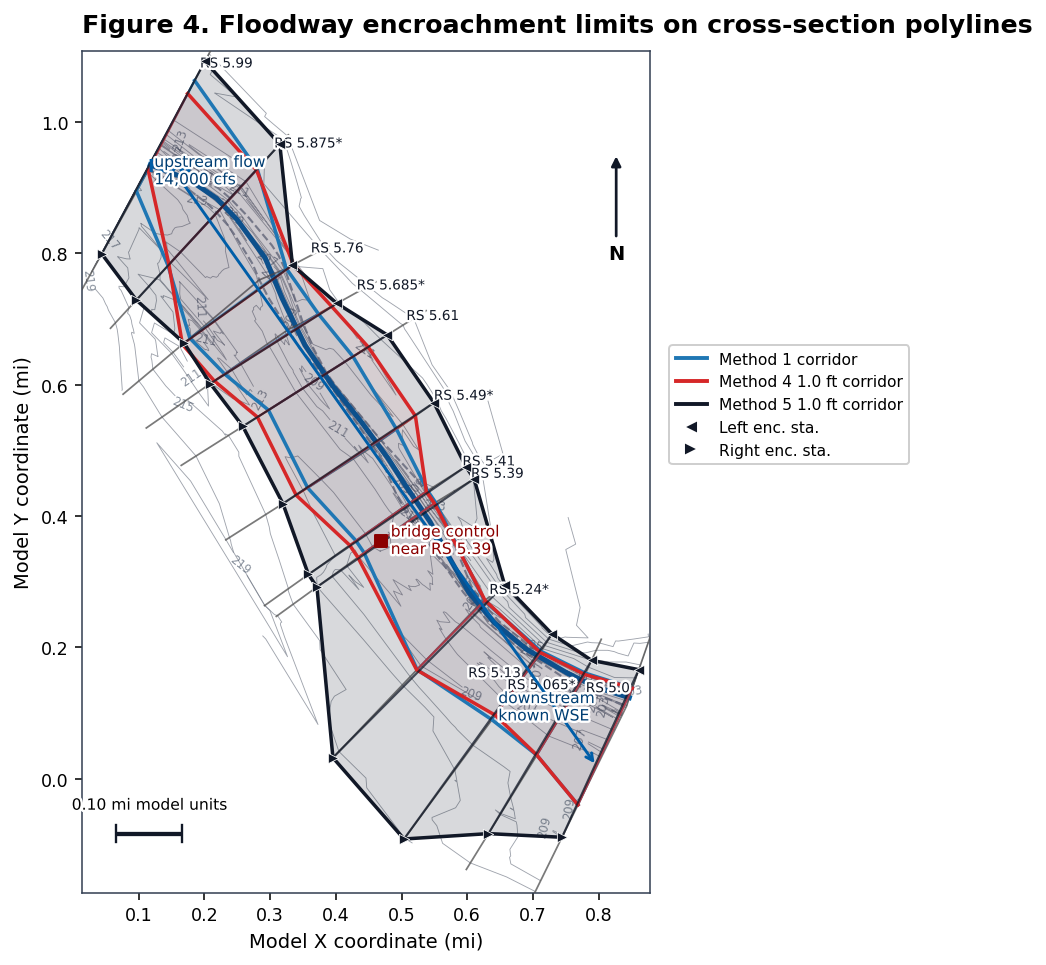

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_terrain_context(ax, geometry_xs, filled=False, alpha=0.18)
plot_model_context(ax, geometry_xs, river_reaches, bank_lines, label_xs=True)

corridor_methods = ["Method 1", "Method 4 1.0 ft", "Method 5 1.0 ft"]
for method in corridor_methods:
    plot_encroachment_corridor(
        ax,
        widths,
        geometry_xs,
        method,
        color=METHOD_COLORS[method],
        fill_alpha=0.16 if method == "Method 5 1.0 ft" else 0.06,
        mark_points=(method == "Method 5 1.0 ft"),
    )

finish_plan_map(ax, "Figure 4. Floodway encroachment limits on cross-section polylines")
legend_handles = [
    Line2D([0], [0], color=METHOD_COLORS["Method 1"], lw=2.0, label="Method 1 corridor"),
    Line2D([0], [0], color=METHOD_COLORS["Method 4 1.0 ft"], lw=2.0, label="Method 4 1.0 ft corridor"),
    Line2D([0], [0], color=METHOD_COLORS["Method 5 1.0 ft"], lw=2.0, label="Method 5 1.0 ft corridor"),
    Line2D([0], [0], marker="<", color="w", markerfacecolor=METHOD_COLORS["Method 5 1.0 ft"], markersize=7, label="Left enc. sta."),
    Line2D([0], [0], marker=">", color="w", markerfacecolor=METHOD_COLORS["Method 5 1.0 ft"], markersize=7, label="Right enc. sta."),
]
ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.02, 0.58), frameon=True, framealpha=0.95)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


## Cross Section Detail Views

The representative cross-section panels show how encroachment limits relate to ground, banks, and water surface at upstream, bridge-control, and downstream locations. The shaded floodway fringe is the encroached overbank area outside the left/right encroachment stations; the green band is the remaining floodway corridor.


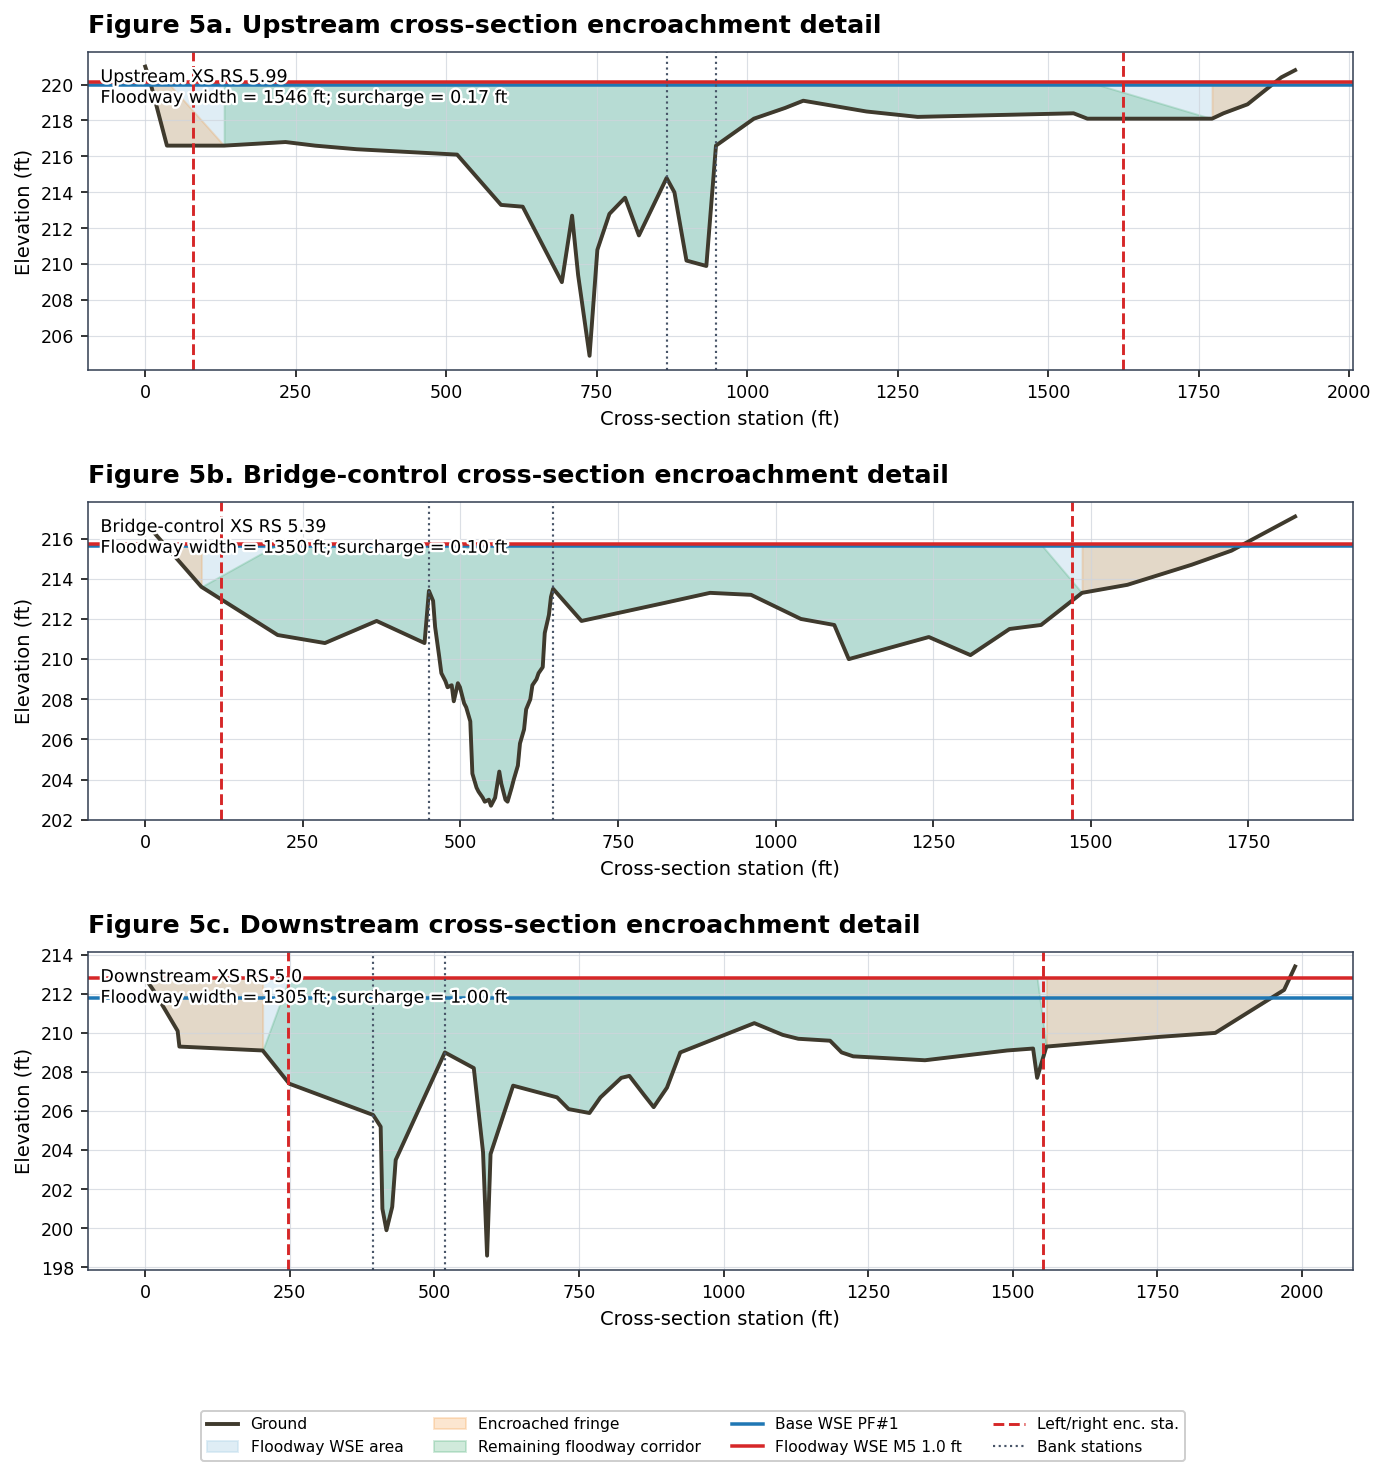

In [11]:
def profile_wse(results_df, station_num, profile_name):
    matches = results_df[
        np.isclose(results_df["station_num"], station_num)
        & (results_df["profile"] == profile_name)
    ]
    if matches.empty:
        return np.nan
    return float(matches.iloc[0]["wsel"])


m5_results = HdfResultsPlan.get_steady_results(hdf_plan_path(plan_m5))
m5_results["station_num"] = m5_results["node_id"].map(clean_station)
final_method = "Method 5 1.0 ft"
final_widths = widths[(widths["method"] == final_method) & widths["floodway_width"].notna()].copy()

representative_targets = [geometry_xs["station_num"].max(), 5.39, geometry_xs["station_num"].min()]
representative_labels = ["Upstream", "Bridge-control", "Downstream"]
representatives = []
for label, target in zip(representative_labels, representative_targets):
    idx = (geometry_xs["station_num"] - target).abs().idxmin()
    station_num = float(geometry_xs.loc[idx, "station_num"])
    if station_num not in [item[1] for item in representatives]:
        representatives.append((label, station_num))

fig, axes = plt.subplots(len(representatives), 1, figsize=(10, 3.55 * len(representatives)), sharex=False)
if len(representatives) == 1:
    axes = [axes]

legend_handles = {}
panel_letters = ["5a", "5b", "5c"]
for panel_index, (ax, (panel_label, station_num)) in enumerate(zip(axes, representatives)):
    xs_row = geometry_xs[np.isclose(geometry_xs["station_num"], station_num)].iloc[0]
    section = pd.DataFrame(np.asarray(xs_row["station_elevation"], dtype=float), columns=["station", "elev"])
    section = section.sort_values("station")
    enc = final_widths[np.isclose(final_widths["station_num"], station_num)].iloc[0]
    base_wse = profile_wse(m5_results, station_num, "PF#1")
    floodway_wse = profile_wse(m5_results, station_num, "M5 1.0 ft")

    ax.plot(section["station"], section["elev"], color=HEC_COLORS["ground"], lw=2.0, label="Ground")
    ax.fill_between(
        section["station"],
        section["elev"],
        floodway_wse,
        where=section["elev"] <= floodway_wse,
        color="#b9d9eb",
        alpha=0.45,
        interpolate=True,
        label="Floodway WSE area",
    )

    left_mask = section["station"] <= enc["encroach_left"]
    right_mask = section["station"] >= enc["encroach_right"]
    corridor_mask = (section["station"] >= enc["encroach_left"]) & (section["station"] <= enc["encroach_right"])
    for mask, color, label in [
        (left_mask, HEC_COLORS["fringe"], "Encroached fringe"),
        (right_mask, HEC_COLORS["fringe"], None),
        (corridor_mask, HEC_COLORS["corridor"], "Remaining floodway corridor"),
    ]:
        ax.fill_between(
            section["station"],
            section["elev"],
            floodway_wse,
            where=mask & (section["elev"] <= floodway_wse),
            color=color,
            alpha=0.22,
            interpolate=True,
            label=label,
        )

    ax.axhline(base_wse, color=HEC_COLORS["base"], lw=1.8, label="Base WSE PF#1")
    ax.axhline(floodway_wse, color=HEC_COLORS["floodway"], lw=1.8, label="Floodway WSE M5 1.0 ft")
    ax.axvline(enc["encroach_left"], color=HEC_COLORS["floodway"], lw=1.5, ls="--", label="Left/right enc. sta.")
    ax.axvline(enc["encroach_right"], color=HEC_COLORS["floodway"], lw=1.5, ls="--")
    ax.axvline(float(xs_row["Left Bank"]), color="#475467", lw=1.1, ls=":", label="Bank stations")
    ax.axvline(float(xs_row["Right Bank"]), color="#475467", lw=1.1, ls=":")

    surcharge = floodway_wse - base_wse
    annotation = (
        f"{panel_label} XS RS {format_station_label(xs_row['RS'])}\n"
        f"Floodway width = {enc['floodway_width']:.0f} ft; surcharge = {surcharge:.2f} ft"
    )
    text = ax.text(0.01, 0.95, annotation, transform=ax.transAxes, ha="left", va="top", fontsize=9)
    apply_text_outline(text)
    format_hec_axis(
        ax,
        f"Figure {panel_letters[panel_index]}. {panel_label} cross-section encroachment detail",
        "Cross-section station (ft)",
        "Elevation (ft)",
    )
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label and label not in legend_handles:
            legend_handles[label] = handle

fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    framealpha=0.95,
)
plt.tight_layout(rect=[0, 0.09, 1, 1], h_pad=1.8)
plt.show()


## Surcharge Comparison And Pass/Fail Summary

The final review mirrors HEC floodway table checks by comparing the natural/base profile to each encroached profile at every cross section. The primary surcharge figure highlights the Method 5 1.0 ft profile; the summary chart then checks every authored method against the 1.0 ft allowable rise used in this example.


,method,profile,sections,min_surcharge_ft,mean_surcharge_ft,max_surcharge_ft,status
0,Method 1,PF#2,12,0.11,0.81,1.00,PASS
1,Method 2,PF#2,12,0.43,0.99,1.57,REVIEW
2,Method 3,PF#2,12,0.31,0.93,1.31,REVIEW
3,Method 4 0.5 ft,M4 0.5 ft,12,-0.15,0.39,1.00,PASS
4,Method 4 1.0 ft,M4 1.0 ft,12,0.16,0.75,1.12,REVIEW
5,Method 5 0.5 ft,M5 0.5 ft,12,-0.42,0.20,1.00,PASS
6,Method 5 1.0 ft,M5 1.0 ft,12,-0.41,0.15,1.00,PASS


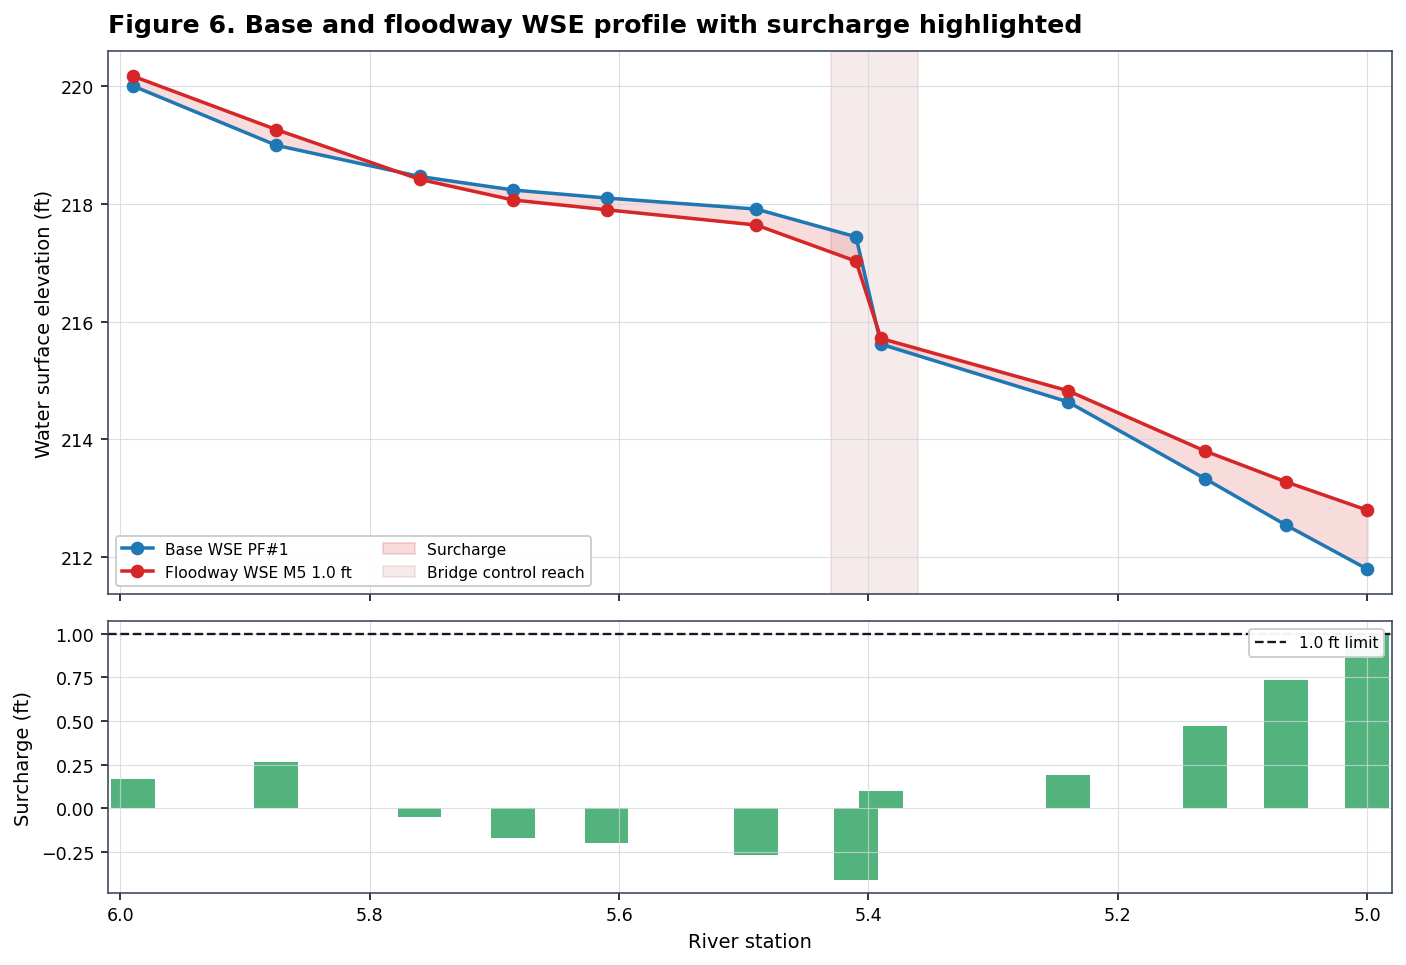

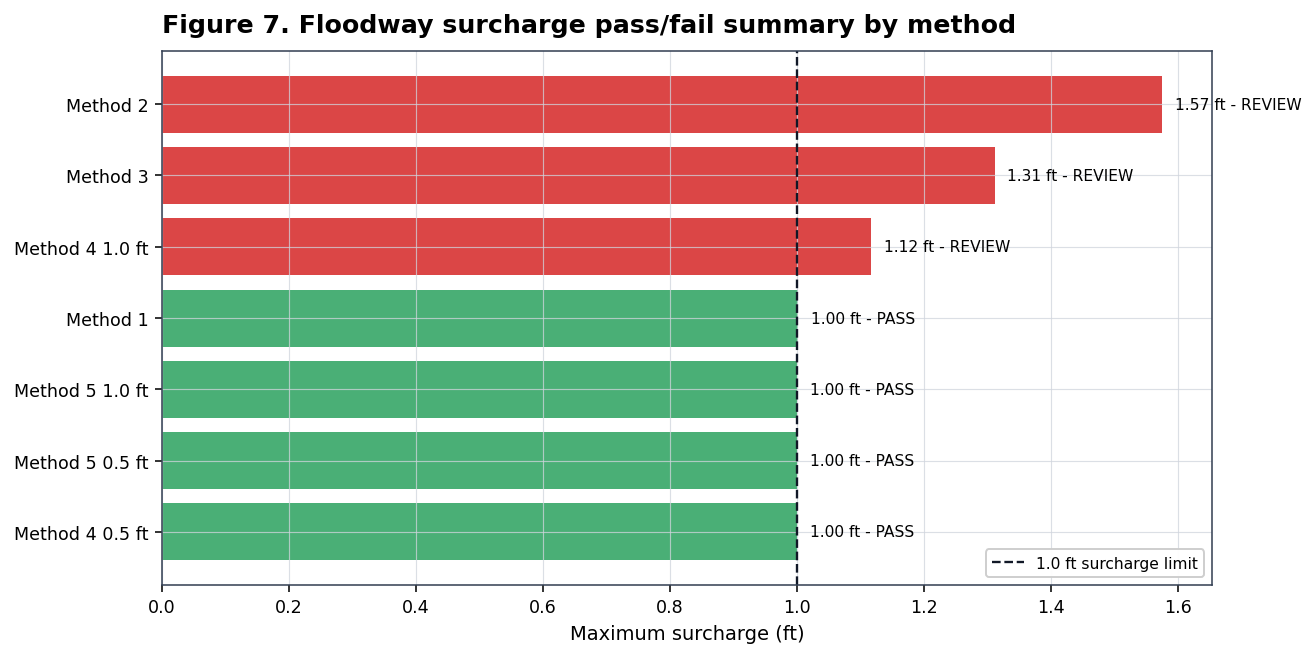

In [12]:
def compute_surcharge_table(method_label: str, plan_number: str, floodway_profile: str) -> pd.DataFrame:
    results = HdfResultsPlan.get_steady_results(hdf_plan_path(plan_number)).copy()
    results["station_num"] = results["node_id"].map(clean_station)
    base = (
        results[results["profile"] == "PF#1"]
        [["river", "reach", "node_id", "station_num", "wsel"]]
        .rename(columns={"wsel": "base_wsel"})
    )
    floodway = (
        results[results["profile"] == floodway_profile]
        [["node_id", "station_num", "wsel"]]
        .rename(columns={"wsel": "floodway_wsel"})
    )
    merged = base.merge(floodway, on=["node_id", "station_num"], how="inner")
    merged["method"] = method_label
    merged["profile"] = floodway_profile
    merged["surcharge_ft"] = merged["floodway_wsel"] - merged["base_wsel"]
    return merged


surcharge_df = pd.concat(
    [
        compute_surcharge_table(label, info["plan"], info["floodway_profile"])
        for label, info in authored_plans.items()
    ],
    ignore_index=True,
)

surcharge_summary = (
    surcharge_df.groupby(["method", "profile"], as_index=False)
    .agg(
        sections=("station_num", "count"),
        min_surcharge_ft=("surcharge_ft", "min"),
        mean_surcharge_ft=("surcharge_ft", "mean"),
        max_surcharge_ft=("surcharge_ft", "max"),
    )
)
surcharge_summary["status"] = np.where(
    surcharge_summary["max_surcharge_ft"] <= SURCHARGE_LIMIT_FT + 0.005,
    "PASS",
    "REVIEW",
)
surcharge_summary["method"] = pd.Categorical(surcharge_summary["method"], categories=method_order, ordered=True)
surcharge_summary = surcharge_summary.sort_values("method")
display(
    surcharge_summary.style.format({
        "min_surcharge_ft": "{:.2f}",
        "mean_surcharge_ft": "{:.2f}",
        "max_surcharge_ft": "{:.2f}",
    })
)

primary = surcharge_df[surcharge_df["method"] == final_method].sort_values("station_num")
fig, (ax_wse, ax_surcharge) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, height_ratios=[2.0, 1.0])
ax_wse.plot(primary["station_num"], primary["base_wsel"], marker="o", color=HEC_COLORS["base"], lw=1.8, label="Base WSE PF#1")
ax_wse.plot(primary["station_num"], primary["floodway_wsel"], marker="o", color=HEC_COLORS["floodway"], lw=1.8, label="Floodway WSE M5 1.0 ft")
ax_wse.fill_between(
    primary["station_num"].to_numpy(),
    primary["base_wsel"].to_numpy(),
    primary["floodway_wsel"].to_numpy(),
    color=HEC_COLORS["floodway"],
    alpha=0.16,
    label="Surcharge",
)
ax_wse.axvspan(5.36, 5.43, color="#8b0000", alpha=0.08, label="Bridge control reach")
format_hec_axis(
    ax_wse,
    "Figure 6. Base and floodway WSE profile with surcharge highlighted",
    "",
    "Water surface elevation (ft)",
    invert_station=True,
)
ax_wse.legend(ncol=2, loc="best", frameon=True, framealpha=0.95)

bar_colors = np.where(primary["surcharge_ft"] <= SURCHARGE_LIMIT_FT + 0.005, "#2ca25f", "#d62728")
ax_surcharge.bar(primary["station_num"], primary["surcharge_ft"], width=0.035, color=bar_colors, alpha=0.82)
ax_surcharge.axhline(SURCHARGE_LIMIT_FT, color="#111827", ls="--", lw=1.2, label="1.0 ft limit")
format_hec_axis(
    ax_surcharge,
    "",
    "River station",
    "Surcharge (ft)",
    invert_station=False,
)
ax_surcharge.set_xlim(primary["station_num"].max() + 0.02, primary["station_num"].min() - 0.02)
ax_surcharge.legend(loc="upper right", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
summary_plot = surcharge_summary.sort_values("max_surcharge_ft", ascending=True)
status_colors = summary_plot["status"].map({"PASS": "#2ca25f", "REVIEW": "#d62728"}).to_list()
ax.barh(summary_plot["method"].astype(str), summary_plot["max_surcharge_ft"], color=status_colors, alpha=0.86)
ax.axvline(SURCHARGE_LIMIT_FT, color="#111827", ls="--", lw=1.2, label="1.0 ft surcharge limit")
for y, (_, row) in enumerate(summary_plot.iterrows()):
    ax.text(row["max_surcharge_ft"] + 0.02, y, f"{row['max_surcharge_ft']:.2f} ft - {row['status']}", va="center", fontsize=8)
format_hec_axis(
    ax,
    "Figure 7. Floodway surcharge pass/fail summary by method",
    "Maximum surcharge (ft)",
    "",
)
ax.legend(loc="lower right", frameon=True, framealpha=0.95)
plt.tight_layout()
plt.show()
